In [ ]:
from rubin_sim import maf
from rubin_sim.data import get_data_dir

try:
    from rubin_sim.data import get_baseline
except ImportError:
    from rubin_scheduler.data import get_baseline
import rubin_sim
from rubin_sim import data
from rubin_sim.data import get_baseline
import healpy as hp
import numpy as np
import sqlite3
from astropy.coordinates import SkyCoord
import astropy.units as u
import datashader as ds
import matplotlib.pyplot as plt
import matplotlib as mpl
from datashader.mpl_ext import dsshow
import pandas as pd
import galsim
import matplotlib.lines as mlines

# # set up the outdir
# outdir = 'test'
# import os
# os.makedirs(outdir, exist_ok=True)

opsim_fname = "/Users/msredden/Documents/DESC/DifferentialCR/db files/baseline_v5.1.0_10yrs.db" #get_baseline() "
print(opsim_fname)

con = sqlite3.connect(opsim_fname)
cur = con.cursor()

cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cur.fetchall()
print("Tables:", tables)

table_name = 'observations'  # replace with the actual table name
cur.execute(f"PRAGMA table_info({table_name});")
columns = cur.fetchall()
column_names = [col[1] for col in columns]
print("Column Names:", column_names)

/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/msredden/rubin_sim_data/sim_baseline/baseline_v4.3.1_10yrs.db
Tables: [('observations',), ('info',), ('events',)]
Column Names: ['observationId', 'fieldRA', 'fieldDec', 'observationStartMJD', 'flush_by_mjd', 'visitExposureTime', 'band', 'filter', 'rotSkyPos', 'rotSkyPos_desired', 'numExposures', 'airmass', 'seeingFwhm500', 'seeingFwhmEff', 'seeingFwhmGeom', 'skyBrightness', 'night', 'slewTime', 'visitTime', 'slewDistance', 'fiveSigmaDepth', 'altitude', 'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt', 'scheduler_note', 'target_name', 'target_id', 'observationStartLST', 'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec', 'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase', 'cummTelAz', 'observation_reason', 'science_program']


In [ ]:
nside = 128

# example4_bundles = {
#     "airmass": maf.MetricBundle(
#         metric=maf.PercentileMetric(col="airmass", percentile = 50),
#         slicer=maf.slicers.HealpixSlicer(nside=nside),
#         constraint="filter = 'i'",
#         plot_dict={"color": "g"},
#         # run_name=run_name,
#     ),
#     "cosmology": maf.MetricBundle(
#         metric=maf.metrics.ExgalM5WithCuts(lsst_filter="i", extinction_cut=0.2,
#                                     depth_cut=25.9, n_filters=6,
#                                     ),
#         slicer=maf.slicers.HealpixSlicer(nside=nside),
#         constraint="scheduler_note not like '%DD%'",
#         plot_dict={"color": "r"},
#         # run_name=run_name,
#     ),
# }

example_bundle = {"parallactic angle": maf.MetricBundle(
        metric=maf.CountMetric(col="PA"),
        slicer=maf.OneDSlicer(slice_col_name="PA", bin_min=-360, bin_max=360, bin_size=2),
        constraint="not (scheduler_note = 'twilight_near_sun, 0' or scheduler_note = 'twilight_near_sun, 1' or scheduler_note = 'twilight_near_sun, 2' or scheduler_note = 'twilight_near_sun, 3')" \
        "and (fieldRA - 53.5 < 0.1 or fieldRA - 53.5 > 359.9) and (fieldDec - (-28) < 0.1 or fieldDec - (-28) > -0.1)",
        plot_dict={'fontsize': 14,
                  'labelsize': 20,
                  'figsize': (5.5, 2.55),
                  'alpha': 1,
                   'x_min': -180,
                   'x_max': 180,
                  'xlabel': 'Parallactic Angle',
                  'ylabel':'Frequency',
                  'title': 'OpSim visits: baseline_v5.1.0_10yrs.db'},
        # run_name=run_name,
    )}

example_bundle = {"parallactic angle": maf.MetricBundle(
        metric=maf.CountMetric(col="PA"),
        slicer=maf.OneDSlicer(slice_col_name="PA", bin_min=-360, bin_max=360, bin_size=2),
        constraint="not (scheduler_note = 'twilight_near_sun, 0' or scheduler_note = 'twilight_near_sun, 1' or scheduler_note = 'twilight_near_sun, 2' or scheduler_note = 'twilight_near_sun, 3')" \
        "and (fieldRA - 53.5 < 0.1 or fieldRA - 53.5 > 359.9) and (fieldDec - (-28) < 0.1 or fieldDec - (-28) > -0.1)",
        plot_dict={'fontsize': 14,
                  'labelsize': 20,
                  'figsize': (5.5, 2.55),
                  'alpha': 1,
                   'x_min': -180,
                   'x_max': 180,
                  'xlabel': 'Parallactic Angle',
                  'ylabel':'Frequency',
                  'title': 'OpSim visits: baseline_v5.1.0_10yrs.db'},
        # run_name=run_name,
    )}


example_bg = maf.MetricBundleGroup(example_bundle, opsim_fname, out_dir='scrap')
example_bg.run_all()

OSError: [Errno 63] File name too long: 'scrap/run_name_Count_PA_not_scheduler_note_twilight_near_sun_0_or_scheduler_note_twilight_near_sun_1_or_scheduler_note_twilight_near_sun_2_or_scheduler_note_twilight_near_sun_3and_fieldRA_-_53_5_lt_0_1_or_fieldRA_-_53_5_gt_359_9_and_fieldDec_-_-28_lt_0_1_or_fieldDec_-_-28_gt_-0_1_ONED.npz'

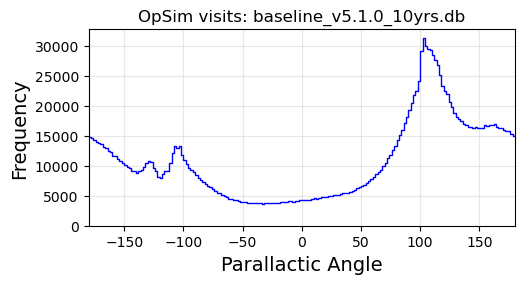

In [16]:
example_bg.plot_all(closefigs=False)